# IBM HR Analysis

## Observations
- Dataset has 34 features plus 1 UID (Empmployee number)
- Categorical Data (7 Features) is already encoded
  - Attrition (True, False)
  - BusinessTravel (Travel_Rarely, Travel_Frequently,  Non-Travel)
  - Department (Research & Development, Sales,  Human Resources)
  - Education Field (Life Sciences, Medical, Marketing,  Technical Degree, Other)
  - Gender (Male, Female)
  - 
  - Already Encoded
    - Education (1 ='Below College', 2 = 'College', 3 = 'Bachelor', 4 = 'Master', 5 'Doctor')
    - EnvironmentSatisfaction (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - JobInvolvement (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - JobSatisfaction (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - PerformanceRating (1 = 'Low', 2 = 'Good', 3 = 'Excellent', 4 = 'Outstanding')
    - RelationshipSatisfaction (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - WorkLifeBalance (1 = 'Bad', 2 = 'Good', 3 = 'Better', 4 = 'Best')

## Objectives & Possible Questions

1. Which factors (e.g., Age, MonthlyIncome, JobRole, WorkLifeBalance, OverTime) are most associated with attrition?
2. Do performance ratings correlate with attrition, and does that relationship vary by job role or tenure?
3. How does compensation (salary, stock options, percent salary hike) relate to voluntary attrition?
4. Are there observable churn patterns by department, job level, or job role?
5. Does overtime or business travel frequency increase attrition risk?
6. How does training time or number of training courses completed affect retention and performance?
7. Are there seasonal or hiring-cohort effects in attrition (e.g., hires in certain years more likely to leave)?
8. What employee segments (clusters) exist based on demographics, performance, and engagement metrics?
9. Does manager effectiveness (e.g., ManagerID patterns or team-level attrition rates) predict individual attrition?
10. How do promotion history and time-in-role affect both performance and attrition risk?
11. What is the survival curve (time-to-attrition) for different employee groups?
12. Can dimensionality reduction (PCA/UMAP) reveal structure or outliers in employee profiles?

## Import Python packages


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ydata_profiling import ProfileReport
import numpy as np
import scipy.stats as ss
import os

/Users/bastianwenzel/CodingSpace/git-repos/ibm-hr-data-challenge/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import data

In [3]:
ibm_df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

ibm_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
print(list(ibm_df.columns))

print(ibm_df.dtypes)

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      in

In [5]:
ibm_df.info()
print(ibm_df.isna().sum())           # missing counts per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## First Look

I am using ydata profiling to take a quick look at the data set

In [6]:
profile = ProfileReport(ibm_df, title="HR Attrittion Profile", explorative=True)

# Save profile report 
# profile.to_file("reports/hr_attrition.html", silent=False)

### Insights surfaced with ydata
1. All of the workers are over 18 ("Over18"), all employees are 1 employee ("EmployeeCount")


### A little bit of descriptive statistics



In [7]:
num = ibm_df.select_dtypes(include=["number"])
print(num.describe().T)

                           count          mean          std     min      25%  \
Age                       1470.0     36.923810     9.135373    18.0    30.00   
DailyRate                 1470.0    802.485714   403.509100   102.0   465.00   
DistanceFromHome          1470.0      9.192517     8.106864     1.0     2.00   
Education                 1470.0      2.912925     1.024165     1.0     2.00   
EmployeeCount             1470.0      1.000000     0.000000     1.0     1.00   
EmployeeNumber            1470.0   1024.865306   602.024335     1.0   491.25   
EnvironmentSatisfaction   1470.0      2.721769     1.093082     1.0     2.00   
HourlyRate                1470.0     65.891156    20.329428    30.0    48.00   
JobInvolvement            1470.0      2.729932     0.711561     1.0     2.00   
JobLevel                  1470.0      2.063946     1.106940     1.0     1.00   
JobSatisfaction           1470.0      2.728571     1.102846     1.0     2.00   
MonthlyIncome             1470.0   6502.

In [8]:
cat_cols = ibm_df.select_dtypes(include=["object", "category"]).columns
for c in cat_cols:
    print("\n", c)
    print(ibm_df[c].value_counts(dropna=False))


 Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

 BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

 Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

 EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

 Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

 JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

 MaritalStatus
MaritalStatus
Married  


## 1. Which factors (e.g., Age, MonthlyIncome, JobRole, WorkLifeBalance, OverTime) are most associated with attrition?

/Users/bastianwenzel/CodingSpace/git-repos/ibm-hr-data-challenge/.venv/lib/python3.9/site-packages/scipy/stats/_stats_py.py:5535: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/2875481609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="r_pb", y="feature", data=corr_df, palette="vlag")


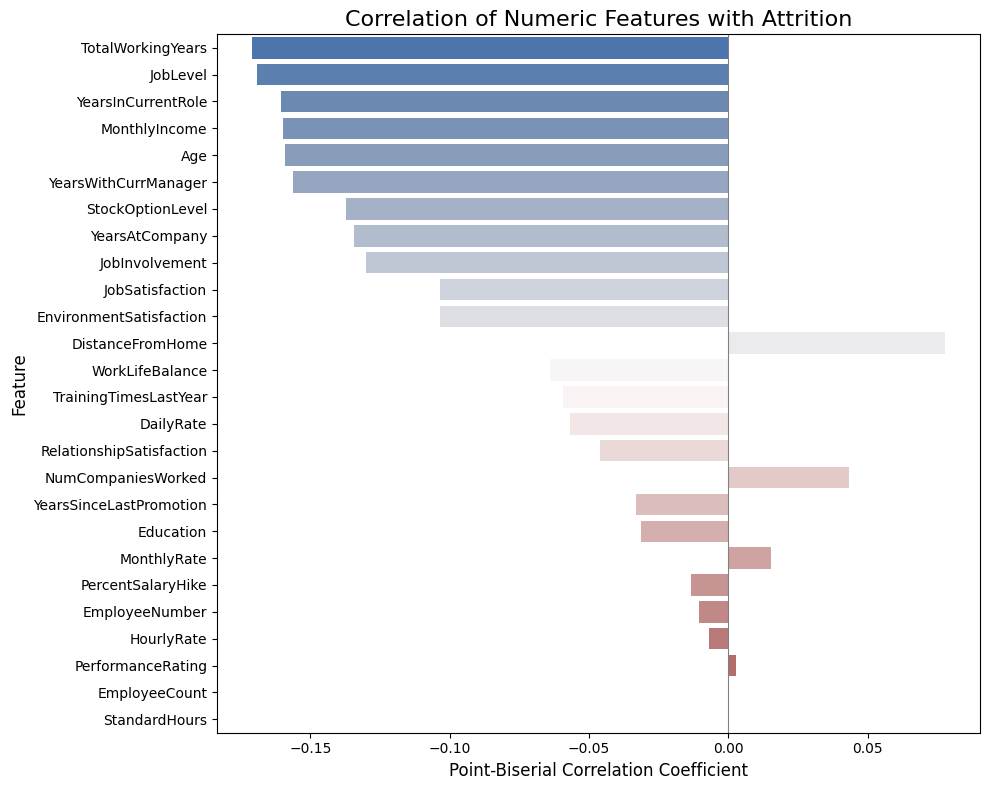

In [9]:
ibm_df["Attrition_bin"] = ibm_df["Attrition"].map({"Yes": 1, "No": 0})

numeric_cols = ibm_df.select_dtypes(include=["number"]).columns.drop("Attrition_bin")
rows = []
for c in numeric_cols:
    r, p = ss.pointbiserialr(ibm_df["Attrition_bin"], ibm_df[c])
    rows.append((c, r, p))

corr_df = pd.DataFrame(rows, columns=["feature", "r_pb", "p_value"])
corr_df= corr_df.sort_values("r_pb", key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="r_pb", y="feature", data=corr_df, palette="vlag")

plt.title("Correlation of Numeric Features with Attrition", fontsize=16)
plt.xlabel("Point-Biserial Correlation Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.axvline(x=0, color='grey', linewidth=0.8)
plt.tight_layout()

corr_df_sorted = corr_df.sort_values("r_pb", key=lambda s: s.abs(), ascending=False)
corr_df_sorted.to_csv("reports/attrition_correlations.csv", index=False)

plt.savefig("reports/attrition_correlation_chart.png")

### Insights

- Strongest Retention Factors:
  - TotalWorkingYears, JobLevel, MonthlyIncome, Age
  - YearsInCurrentRole & YearsWithCurrManager
- Secondary Factors
  - JobSatisfaction & EnvironmentSatisfaction
- Minor influences
  - DistanceFromHome seems to drive people out (but less statistically relevant)

/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/672388354.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/672388354.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='feature', y='cramers_v', data=cramers_v_df, palette='viridis')
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


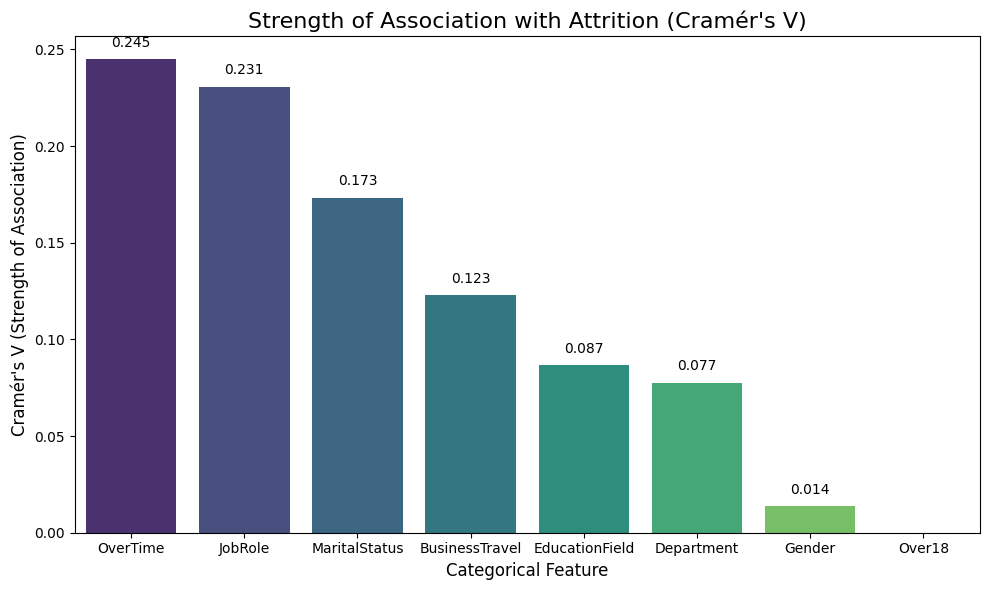

In [14]:
def cramers_v(x, y):
    conf = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(conf, correction=False)[0]
    n = conf.sum().sum()
    phi2 = chi2 / n
    r, k = conf.shape
    # bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = [c for c in cat_cols if c != "Attrition"]
rows = [(c, cramers_v(ibm_df[c], ibm_df["Attrition"])) for c in cat_cols]
cramers_v_df = pd.DataFrame(rows, columns=["feature", "cramers_v"]).sort_values(
    "cramers_v", ascending=False
)

cramers_v_df.to_csv("reports/attrition_cramers_v.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='cramers_v', data=cramers_v_df, palette='viridis')

plt.title("Strength of Association with Attrition (Cramér's V)", fontsize=16)
plt.xlabel("Categorical Feature", fontsize=12)
plt.ylabel("Cramér's V (Strength of Association)", fontsize=12)

for index, value in enumerate(cramers_v_df['cramers_v']):
    plt.text(index, value + 0.005, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

plt.savefig("reports/categorical_feature_chart.png")

### Insights
- OverTime & JobRole are most correlated along with MaritalStatus
- Focus further on OverTime & JobRole (no influence on MaritalStatus)

### Going Forward
- Focus on TotalWorkingYears, JobLevel, MonthlyIncome, Age, YearsInCurrentRole & YearsWithCurrManager
- Also consider Overtime

## 2. Deep Dive into the most important factors

### The Overtime Burnout Hypothesis

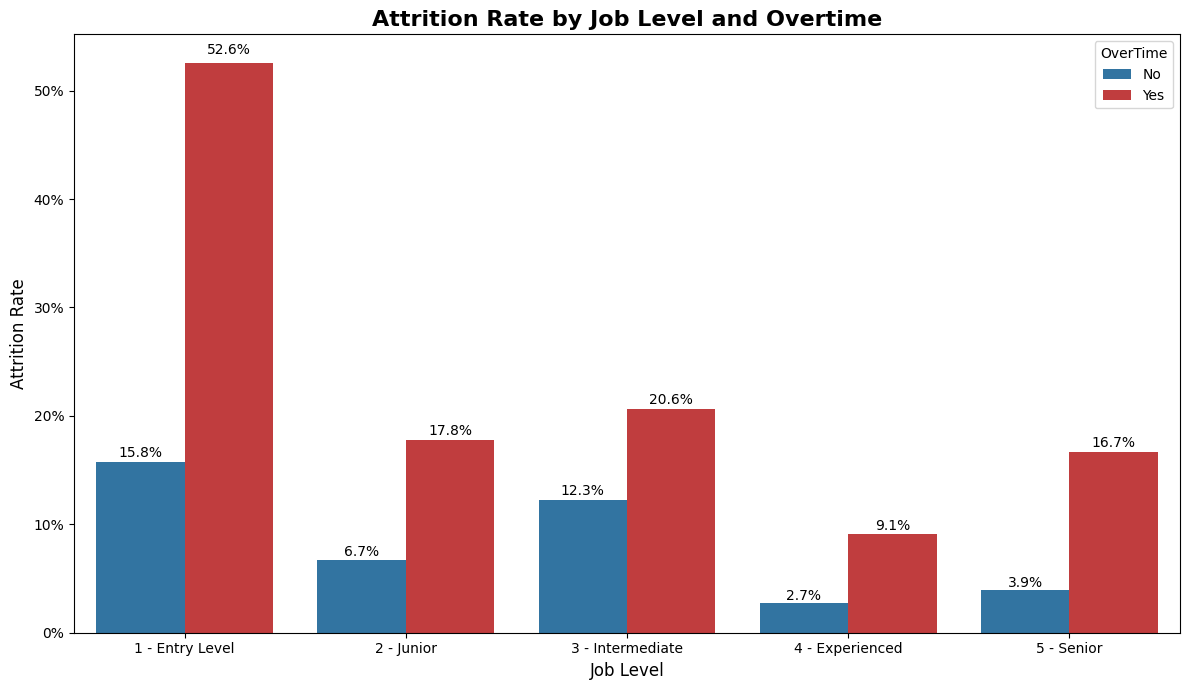

In [11]:
from matplotlib.ticker import PercentFormatter
import json

with open('categorical_data.json', 'r') as f:
    categorical_labels = json.load(f)

attrition_by_group = ibm_df.groupby(['JobLevel', 'OverTime'])['Attrition_bin'].mean().reset_index()
attrition_by_group.to_csv("reports/attrition_by_joblevel_overtime.csv", index=False)

joblevel_map = categorical_labels['JobLevel']['values']
attrition_by_group['JobLevel'] = attrition_by_group['JobLevel'].astype(str).map(joblevel_map)

plt.figure(figsize=(12, 7))

sns.barplot(x='JobLevel', y='Attrition_bin', hue='OverTime', data=attrition_by_group, palette={'Yes': '#d62728', 'No': '#1f77b4'})
plt.title("Attrition Rate by Job Level and Overtime", fontsize=16, weight='bold')
plt.xlabel("Job Level", fontsize=12)
plt.ylabel("Attrition Rate", fontsize=12)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

for p in plt.gca().patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 0: # Avoid labeling bars with zero height
        plt.gca().annotate(f'{height:.1%}', (x + width/2, y + height*1.01), ha='center', va='bottom')

plt.tight_layout()
plt.savefig("reports/attrition_by_joblevel_overtime.png")

#### Insight
- Overtime is highly important and even more impactful on our entry level staff

### How is the Job Role effecting our attrition?

/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/415806584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AttritionRate', y='JobRole', data=job_role_analysis_sorted, palette='plasma')


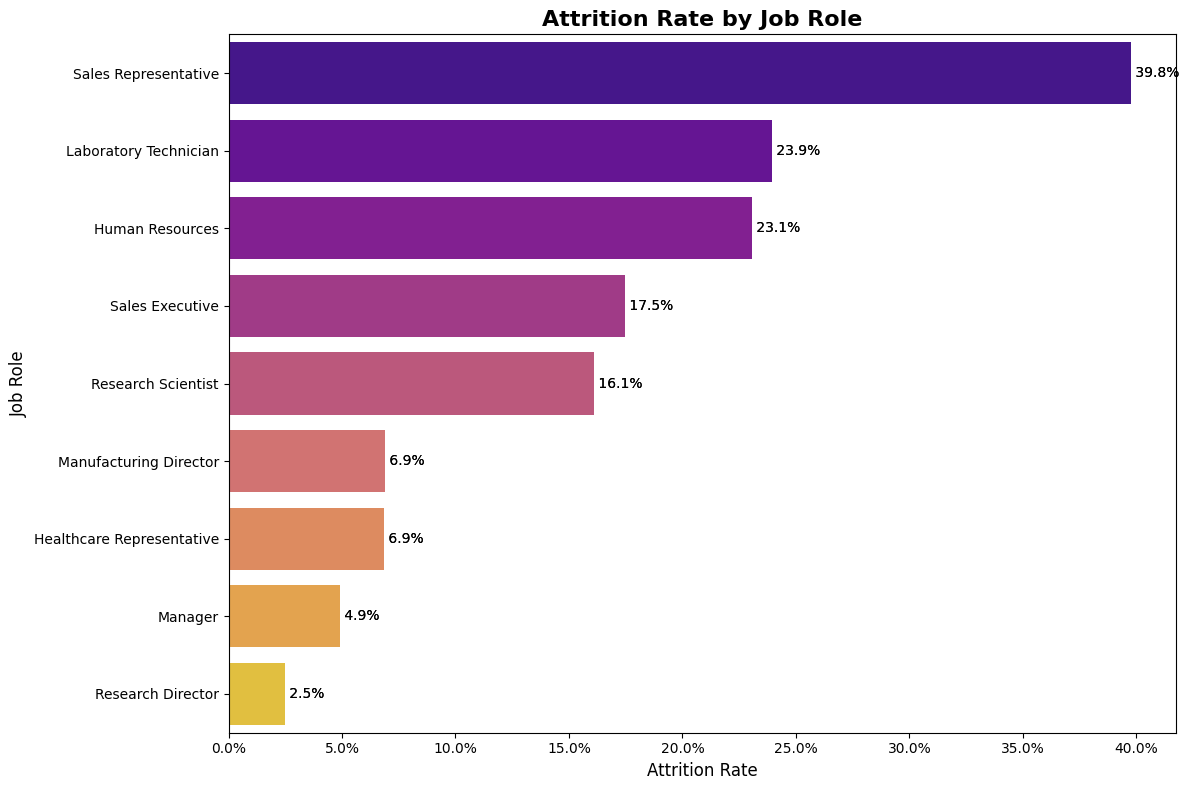

In [12]:
ibm_df["Attrition_bin"] = ibm_df["Attrition"].map({"Yes": 1, "No": 0})

job_role_analysis = ibm_df.groupby('JobRole')['Attrition_bin'].agg(['mean', 'count']).rename(
    columns={'mean': 'AttritionRate', 'count': 'TotalEmployees'})

job_role_analysis_sorted = job_role_analysis.sort_values('AttritionRate', ascending=False)

job_role_analysis_sorted.to_csv("reports/attrition_by_jobrole.csv")

plt.figure(figsize=(12, 8))
sns.barplot(x='AttritionRate', y='JobRole', data=job_role_analysis_sorted, palette='plasma')

plt.title("Attrition Rate by Job Role", fontsize=16, weight='bold')
plt.xlabel("Attrition Rate", fontsize=12)
plt.ylabel("Job Role", fontsize=12)

plt.gca().xaxis.set_major_formatter(PercentFormatter(1))

for index, value in enumerate(job_role_analysis_sorted['AttritionRate']):
    plt.text(value, index, f' {value:.1%}', va='center')
    plt.text(value, index, f' {value:.1%}', va='center')

plt.tight_layout()

plt.savefig("reports/attrition_by_jobrole_chart.png")

#### Insight
- we should start any measures with Sales Reps and Lab Technicians

### How does Income affect attrition?

/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/3136043097.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=ibm_df, palette='pastel')
/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/3136043097.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/3136043097.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/var/folders/zl/szmpd9r53hv421ck3tqlbdhr0000gn/T/ipykernel_8906/3136043097.py:28: Futur

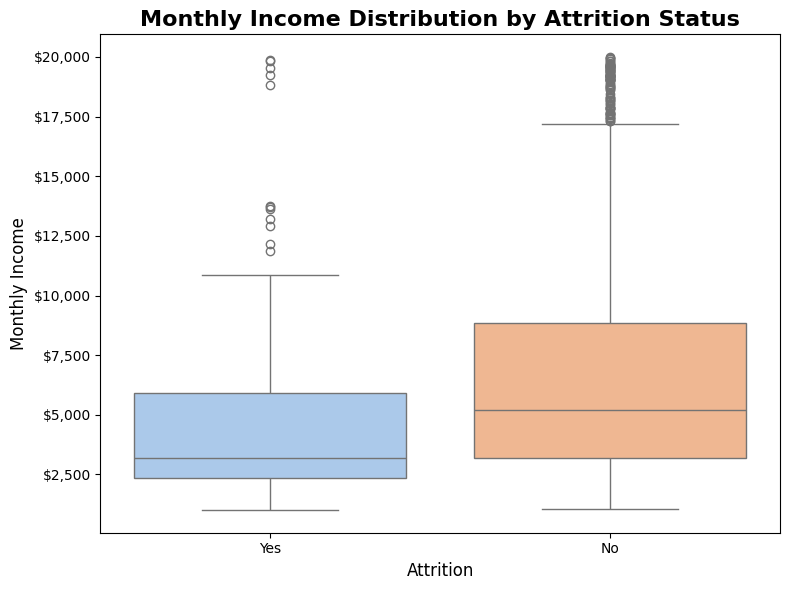

In [13]:
from matplotlib.ticker import FuncFormatter
import re

plt.figure(figsize=(8, 6))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=ibm_df, palette='pastel')

plt.title("Monthly Income Distribution by Attrition Status", fontsize=16, weight='bold')
plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Monthly Income", fontsize=12)

formatter = FuncFormatter(lambda y, pos: f'${int(y):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig("reports/monthly_income_by_attrition_chart.png")

top_roles = ibm_df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
).nlargest(5).index
top_roles_df = ibm_df[ibm_df['JobRole'].isin(top_roles)]

for role in top_roles:
    plt.figure(figsize=(8, 6))
    
    role_data = top_roles_df[top_roles_df['JobRole'] == role]
    
    ax = sns.boxplot(
        data=role_data,
        x='Attrition',
        y='MonthlyIncome',
        order=['Yes', 'No'],
        palette={'Yes': '#d62728', 'No': '#1f77b4'}
    )
    
    ax.set_title(f'Monthly Income Distribution for {role}', fontsize=16, weight='bold')
    ax.set_xlabel('Attrition Status', fontsize=12)
    ax.set_ylabel('Monthly Income', fontsize=12)
    
    formatter = FuncFormatter(lambda y, pos: f'${int(y):,}')
    ax.yaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    safe_filename = re.sub(r'[^a-zA-Z0-9_]', '_', role)
    filename = f"income_boxplot_{safe_filename}.png"
    
    # Save the current figure to a unique file
    plt.savefig(filename)
    plt.close() # Close the figure to free up memory

#### Insight
- Monthly income is a relevant factor and lower income colleauges are more likely to quit

### How does Job Satisfaction affect attrition